# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [1]:
from datetime import datetime, timedelta
import re

end_time = None
start_time = None
elapsed_hms = None

with open("run.log") as f:
    lines = [line.strip() for line in f if line.strip()]

# 最後一行 = End Time
end_time_str = lines[-1]
end_time = datetime.strptime(end_time_str, "%a %b %d %H:%M:%S %Z %Y")

# 找 Total run time
elapsed_sec = None

for line in lines:
    if line.startswith("Total run time"):
        m = re.search(r'([\d.]+)', line)
        if m:
            elapsed_sec = float(m.group(1))
        break

if elapsed_sec is not None:
    start_time = end_time - timedelta(seconds=elapsed_sec)

    h = int(elapsed_sec // 3600)
    m = int((elapsed_sec % 3600) // 60)
    s = int(elapsed_sec % 60)

    elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"End Time   : {end_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"Run Time   : {elapsed_hms}")

Simulation Information
----------------------
Start Time : Sat Jun 27 07:37:10 2026
End Time   : Sat Jun 27 08:40:52 2026
Run Time   : 01:03:41


# 使用者設定

In [2]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -1.000e+10
  BETA = 4.290e+11
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 8.000e-09 m


## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00000444
   plt00000589
   plt00000718
   plt00000916
   plt00004724
   plt00011689
   plt00015624
   plt00018586
   plt00021424
   plt00023524
   plt00023549
   plt00023575
   plt00023602
   plt00023630
   plt00023659
   plt00023690
   plt00023722
   plt00023756
   plt00023791
   plt00023828
   plt00023867
   plt00023913
   plt00023966
   plt00024025
   plt00024090
   plt00024155
   plt00024214
   plt00024275
   plt00024335
   plt00024394
   plt00024458
   plt00024518
   plt00024573
   plt00024621
   plt00024660
   plt00024697
   plt00024733
   plt00024767
   plt00024799
   plt00024830
   plt00024859
   plt00024887
   plt00024914
   plt00024940
   plt00024965
   plt00024989
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-27 09:06:05,718 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-27 09:06:05,719 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:05,721 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:05,722 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_within_domain',
 '_load_requirements',
 '_localize_ch

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotations__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_state
_fill_child_mask
_finalize_parallel

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.95e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.475e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.95e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-27 09:06:05,997 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-27 09:06:05,998 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:05,999 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:06,000 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


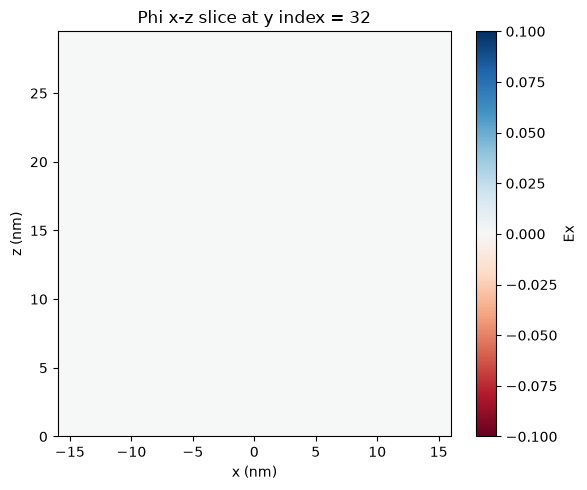

yt : [INFO     ] 2026-06-27 09:06:06,298 Parameters: current_time              = 8.879999999999997e-11


yt : [INFO     ] 2026-06-27 09:06:06,300 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:06,301 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:06,302 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


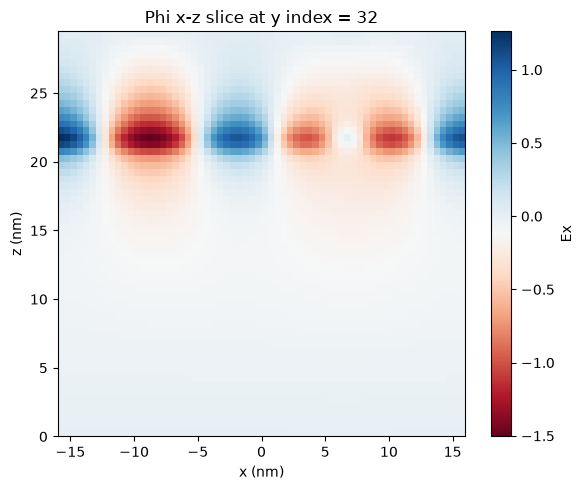

yt : [INFO     ] 2026-06-27 09:06:06,553 Parameters: current_time              = 1.1779999999999958e-10


yt : [INFO     ] 2026-06-27 09:06:06,554 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:06,555 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:06,555 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


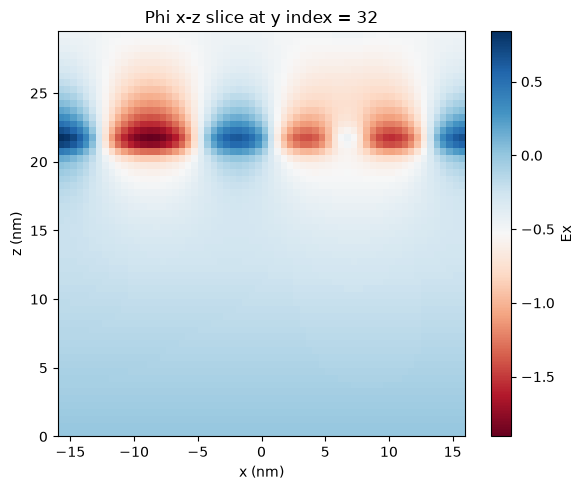

yt : [INFO     ] 2026-06-27 09:06:06,803 Parameters: current_time              = 1.4360000000000083e-10


yt : [INFO     ] 2026-06-27 09:06:06,804 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:06,806 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:06,807 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


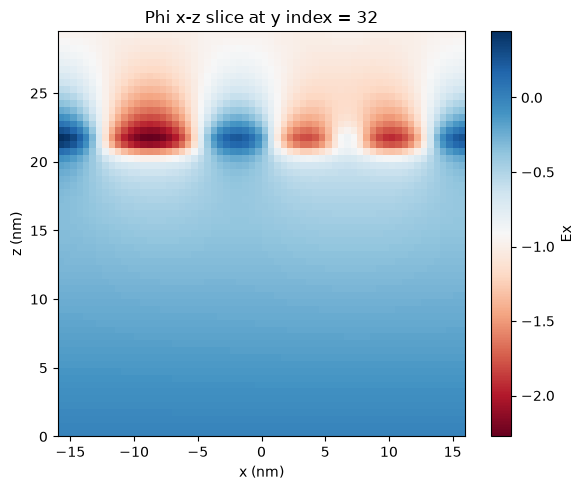

yt : [INFO     ] 2026-06-27 09:06:07,054 Parameters: current_time              = 1.8320000000000274e-10


yt : [INFO     ] 2026-06-27 09:06:07,054 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:07,055 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:07,056 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


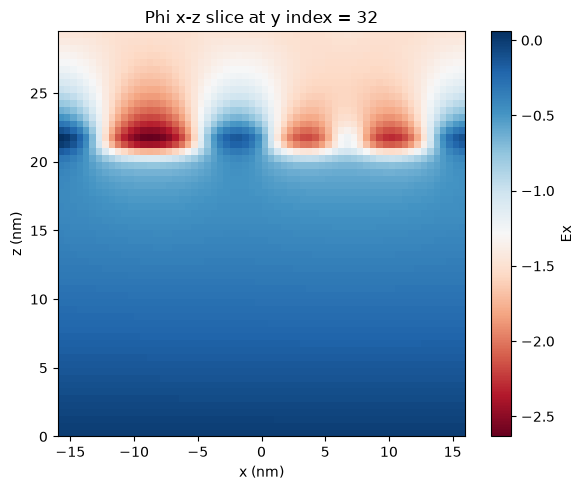

yt : [INFO     ] 2026-06-27 09:06:07,396 Parameters: current_time              = 9.447999999999225e-10


yt : [INFO     ] 2026-06-27 09:06:07,397 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:07,398 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:07,399 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


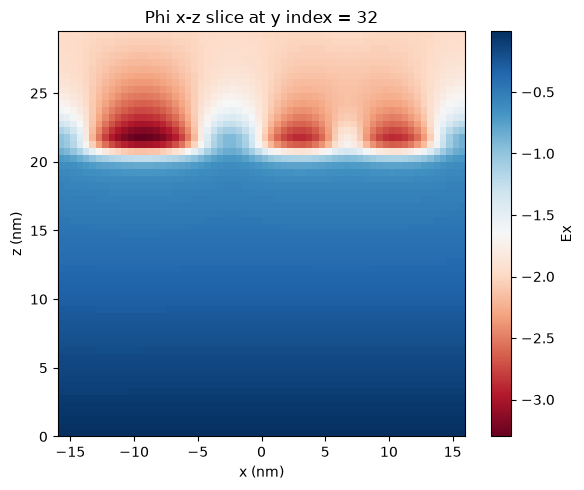

yt : [INFO     ] 2026-06-27 09:06:07,644 Parameters: current_time              = 2.33780000000035e-09


yt : [INFO     ] 2026-06-27 09:06:07,645 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:07,646 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:07,647 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


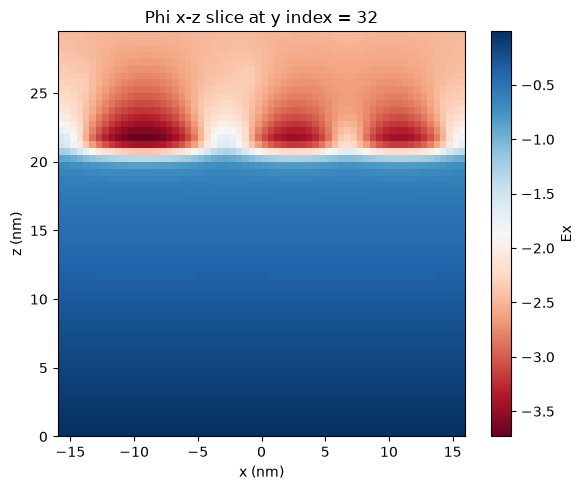

yt : [INFO     ] 2026-06-27 09:06:07,895 Parameters: current_time              = 3.1248000000005912e-09


yt : [INFO     ] 2026-06-27 09:06:07,896 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:07,897 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:07,898 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


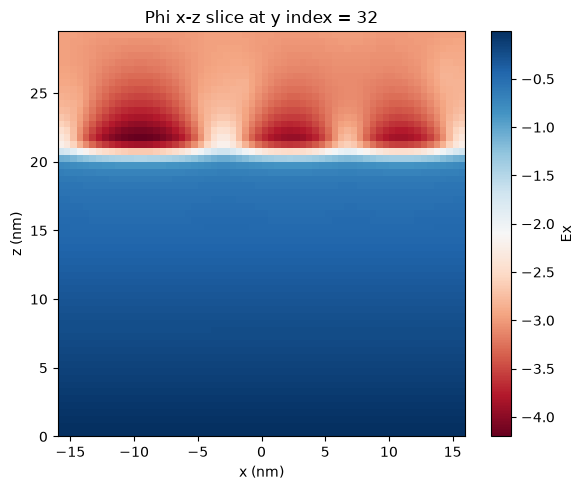

yt : [INFO     ] 2026-06-27 09:06:08,150 Parameters: current_time              = 3.717200000000773e-09


yt : [INFO     ] 2026-06-27 09:06:08,151 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:08,152 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:08,153 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


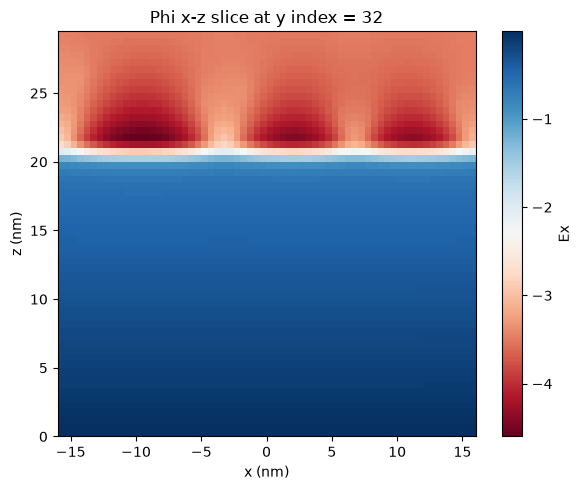

yt : [INFO     ] 2026-06-27 09:06:08,395 Parameters: current_time              = 4.284800000000947e-09


yt : [INFO     ] 2026-06-27 09:06:08,396 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:08,397 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:08,398 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


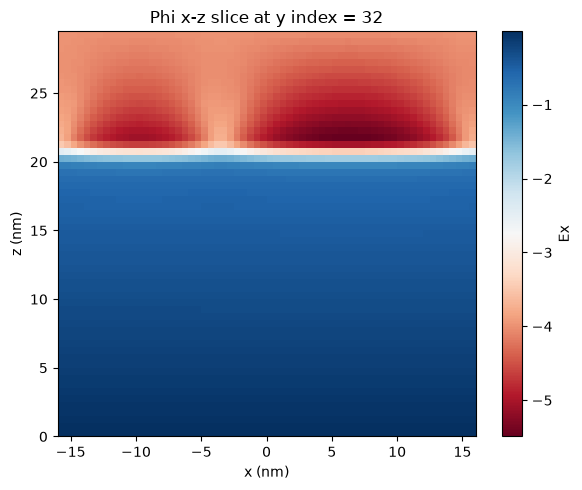

yt : [INFO     ] 2026-06-27 09:06:08,741 Parameters: current_time              = 4.704800000001076e-09


yt : [INFO     ] 2026-06-27 09:06:08,742 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:08,743 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:08,744 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


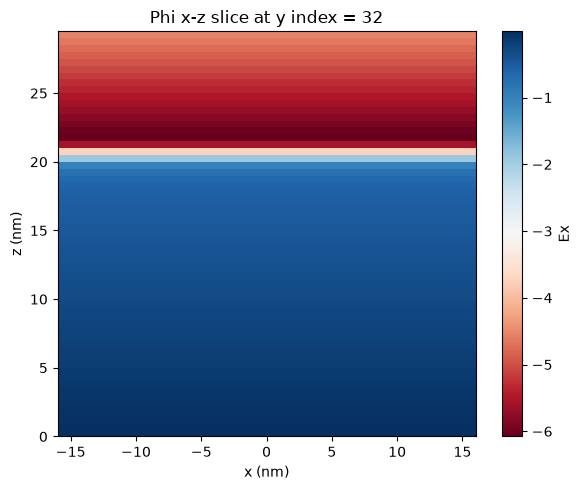

yt : [INFO     ] 2026-06-27 09:06:08,993 Parameters: current_time              = 4.709800000001077e-09


yt : [INFO     ] 2026-06-27 09:06:08,994 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:08,995 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:08,996 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


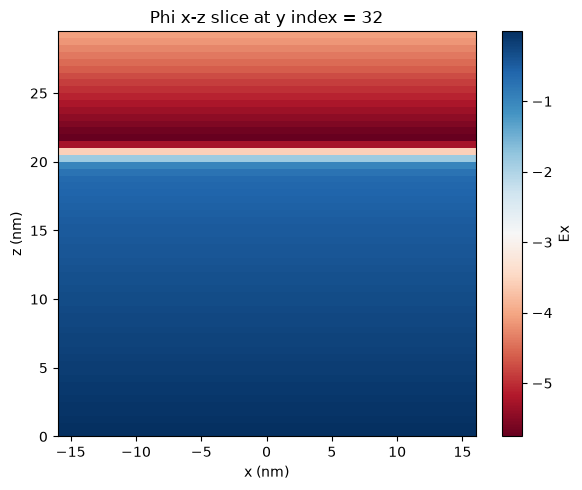

yt : [INFO     ] 2026-06-27 09:06:09,242 Parameters: current_time              = 4.715000000001079e-09


yt : [INFO     ] 2026-06-27 09:06:09,243 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:09,244 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:09,245 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


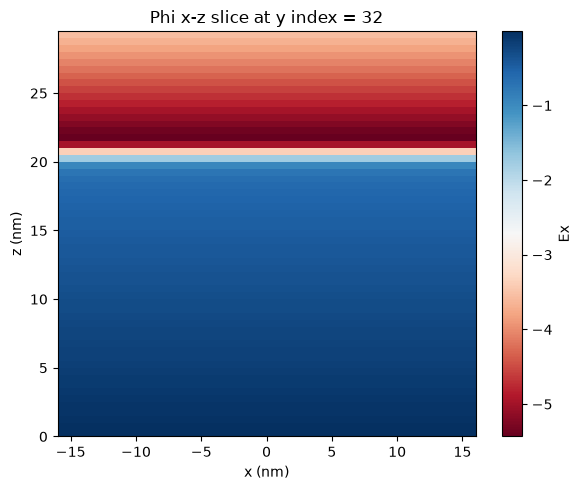

yt : [INFO     ] 2026-06-27 09:06:09,488 Parameters: current_time              = 4.720400000001081e-09


yt : [INFO     ] 2026-06-27 09:06:09,489 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:09,490 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:09,491 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


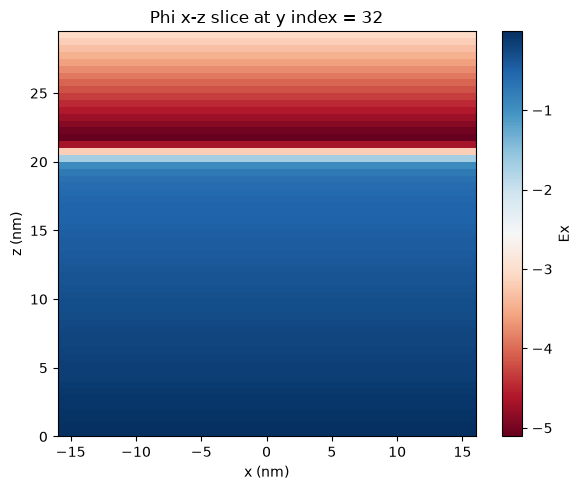

yt : [INFO     ] 2026-06-27 09:06:09,736 Parameters: current_time              = 4.726000000001082e-09


yt : [INFO     ] 2026-06-27 09:06:09,737 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:09,738 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:09,738 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


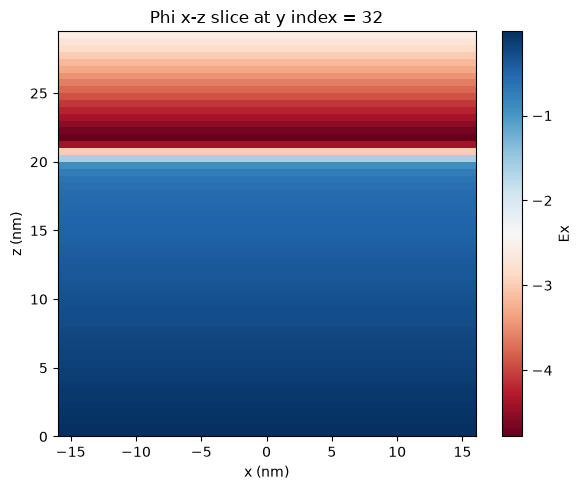

yt : [INFO     ] 2026-06-27 09:06:09,979 Parameters: current_time              = 4.731800000001084e-09


yt : [INFO     ] 2026-06-27 09:06:09,980 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:09,981 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:09,982 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


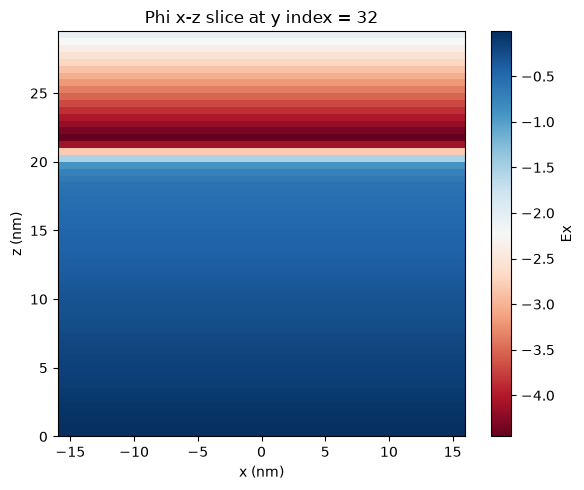

yt : [INFO     ] 2026-06-27 09:06:10,349 Parameters: current_time              = 4.738000000001086e-09


yt : [INFO     ] 2026-06-27 09:06:10,350 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:10,351 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:10,352 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


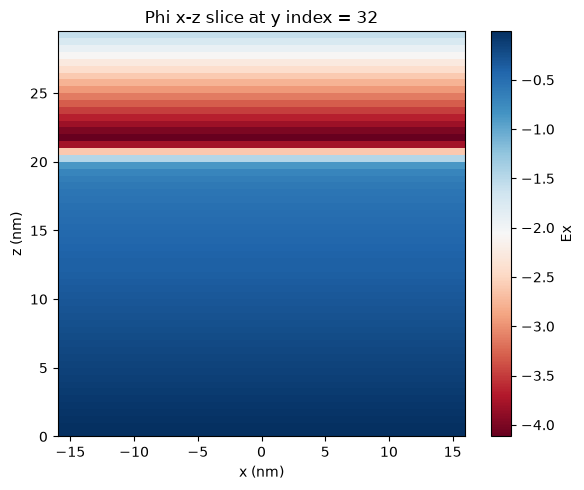

yt : [INFO     ] 2026-06-27 09:06:10,604 Parameters: current_time              = 4.744400000001088e-09


yt : [INFO     ] 2026-06-27 09:06:10,605 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:10,606 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:10,607 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


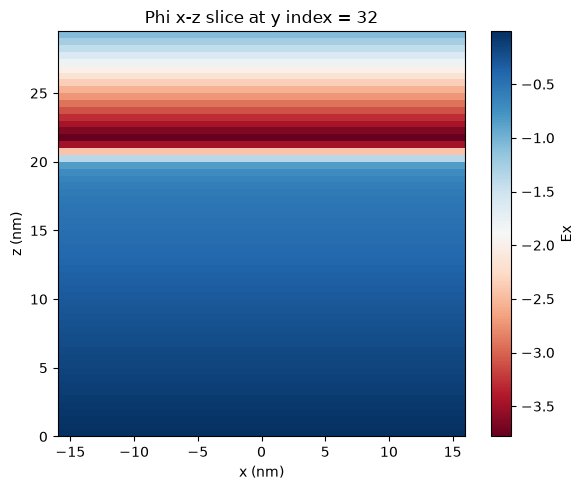

yt : [INFO     ] 2026-06-27 09:06:10,857 Parameters: current_time              = 4.75120000000109e-09


yt : [INFO     ] 2026-06-27 09:06:10,858 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:10,859 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:10,860 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


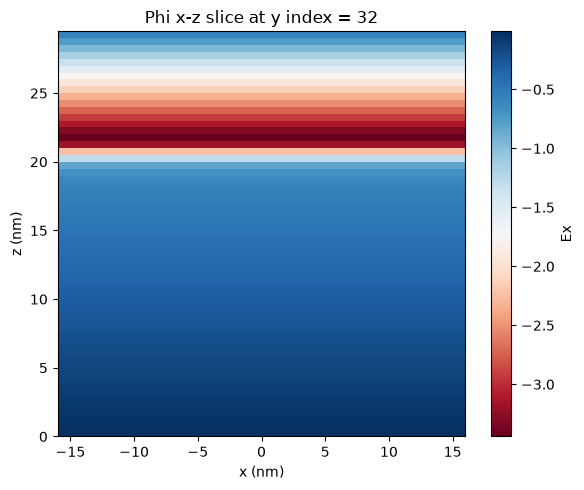

yt : [INFO     ] 2026-06-27 09:06:11,108 Parameters: current_time              = 4.758200000001092e-09


yt : [INFO     ] 2026-06-27 09:06:11,109 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:11,110 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:11,111 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


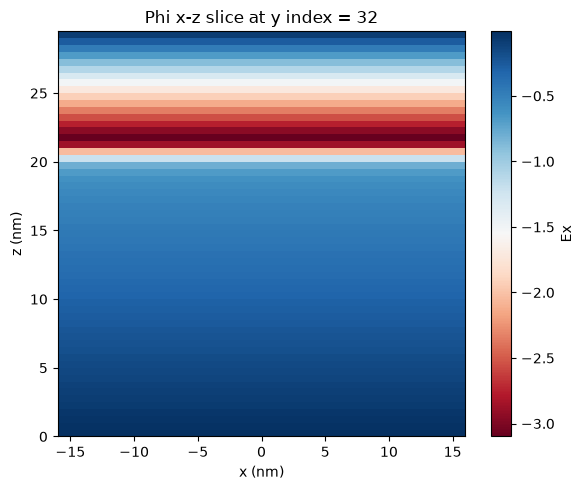

yt : [INFO     ] 2026-06-27 09:06:11,358 Parameters: current_time              = 4.7656000000010945e-09


yt : [INFO     ] 2026-06-27 09:06:11,359 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:11,360 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:11,361 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


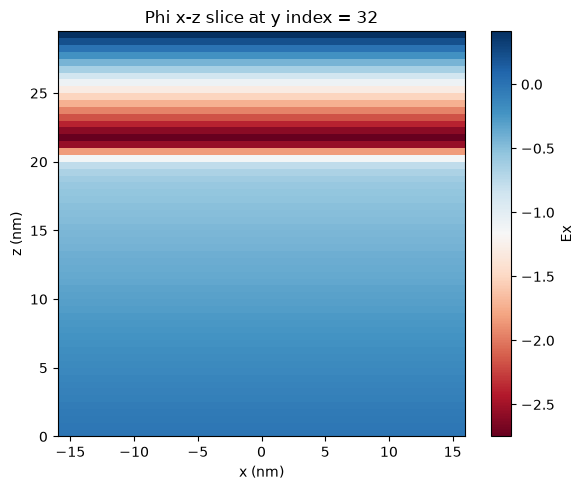

yt : [INFO     ] 2026-06-27 09:06:11,609 Parameters: current_time              = 4.773400000001097e-09


yt : [INFO     ] 2026-06-27 09:06:11,610 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:11,611 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:11,613 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


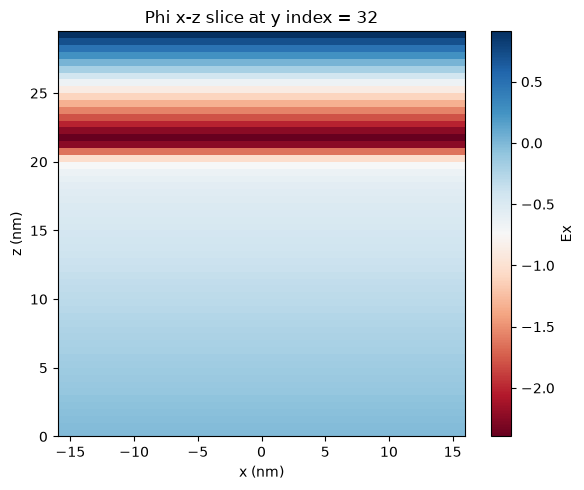

yt : [INFO     ] 2026-06-27 09:06:11,859 Parameters: current_time              = 4.7826000000011e-09


yt : [INFO     ] 2026-06-27 09:06:11,860 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:11,861 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:11,862 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


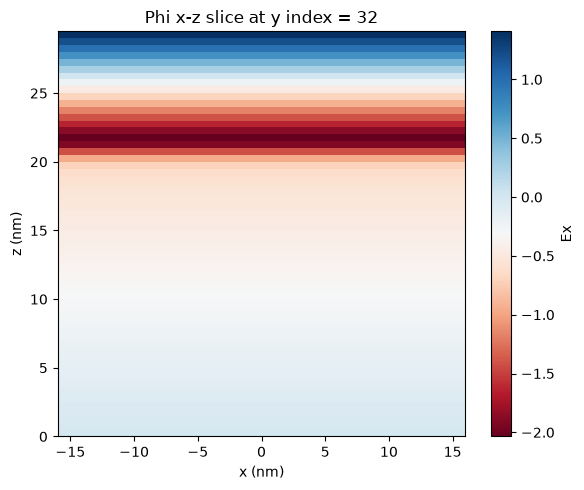

yt : [INFO     ] 2026-06-27 09:06:12,224 Parameters: current_time              = 4.793200000001103e-09


yt : [INFO     ] 2026-06-27 09:06:12,225 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:12,226 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:12,227 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


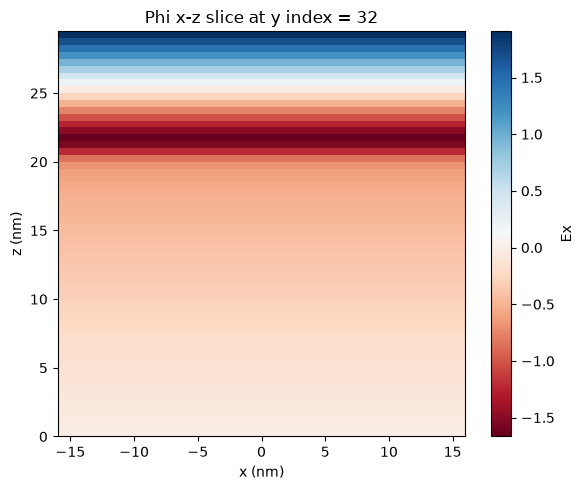

yt : [INFO     ] 2026-06-27 09:06:12,475 Parameters: current_time              = 4.805000000001107e-09


yt : [INFO     ] 2026-06-27 09:06:12,476 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:12,477 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:12,478 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


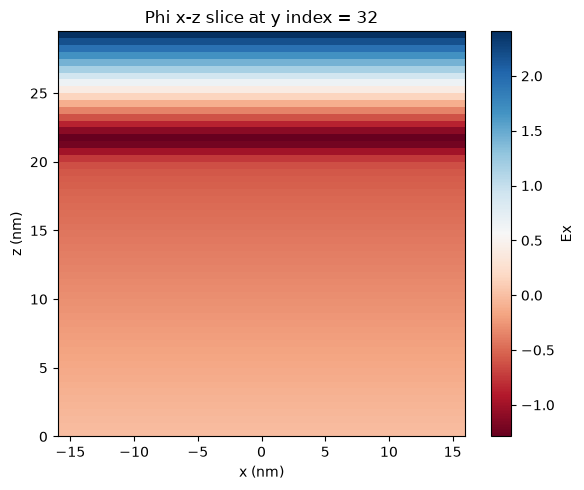

yt : [INFO     ] 2026-06-27 09:06:12,726 Parameters: current_time              = 4.818000000001111e-09


yt : [INFO     ] 2026-06-27 09:06:12,728 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:12,729 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:12,730 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


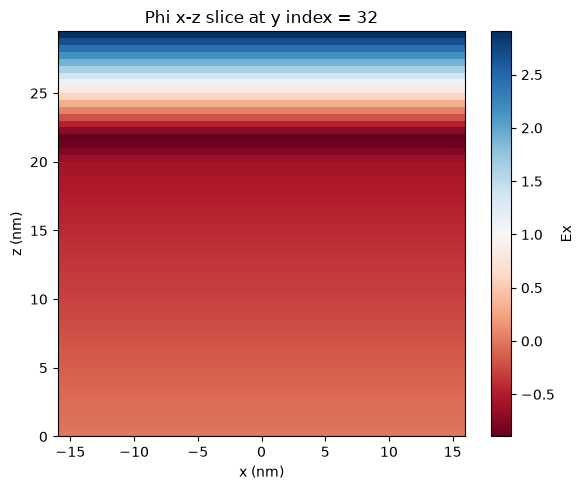

yt : [INFO     ] 2026-06-27 09:06:12,977 Parameters: current_time              = 4.831000000001115e-09


yt : [INFO     ] 2026-06-27 09:06:12,978 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:12,979 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:12,980 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


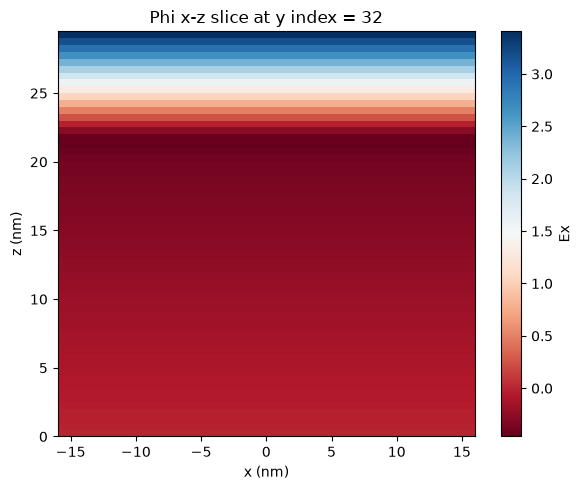

yt : [INFO     ] 2026-06-27 09:06:13,226 Parameters: current_time              = 4.842800000001118e-09


yt : [INFO     ] 2026-06-27 09:06:13,227 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:13,228 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:13,229 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


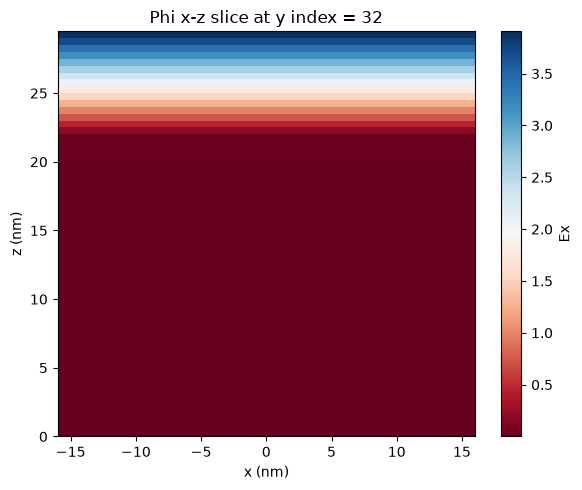

yt : [INFO     ] 2026-06-27 09:06:13,485 Parameters: current_time              = 4.855000000001122e-09


yt : [INFO     ] 2026-06-27 09:06:13,486 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:13,487 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:13,488 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


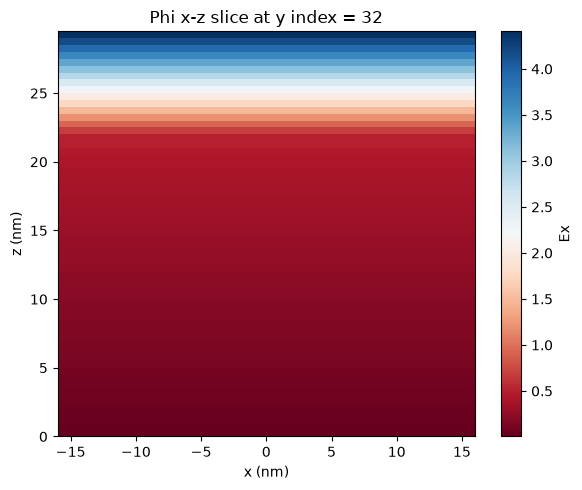

yt : [INFO     ] 2026-06-27 09:06:13,860 Parameters: current_time              = 4.867000000001126e-09


yt : [INFO     ] 2026-06-27 09:06:13,861 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:13,862 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:13,863 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


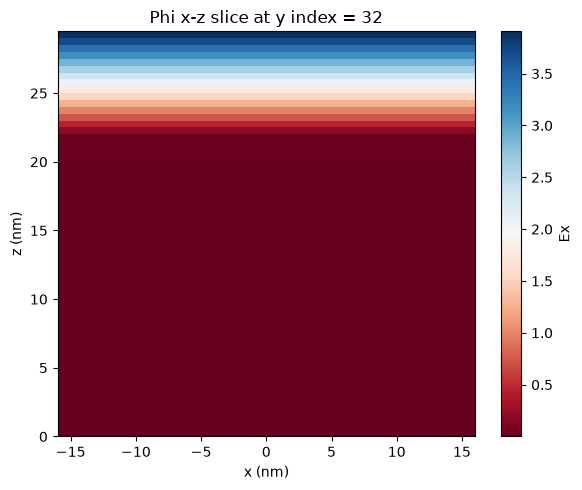

yt : [INFO     ] 2026-06-27 09:06:14,111 Parameters: current_time              = 4.878800000001129e-09


yt : [INFO     ] 2026-06-27 09:06:14,112 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:14,113 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:14,114 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


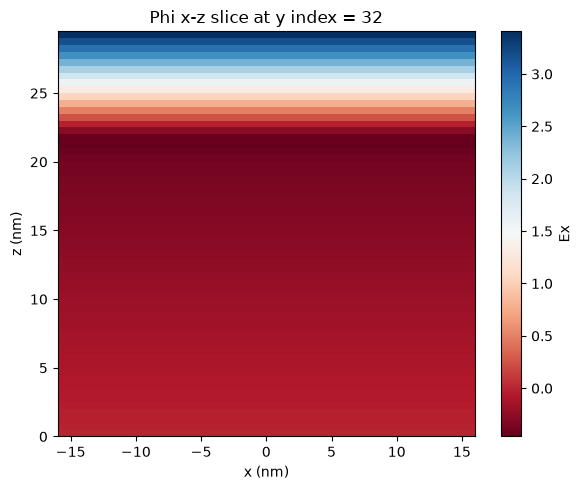

yt : [INFO     ] 2026-06-27 09:06:14,363 Parameters: current_time              = 4.891600000001133e-09


yt : [INFO     ] 2026-06-27 09:06:14,365 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:14,366 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:14,366 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


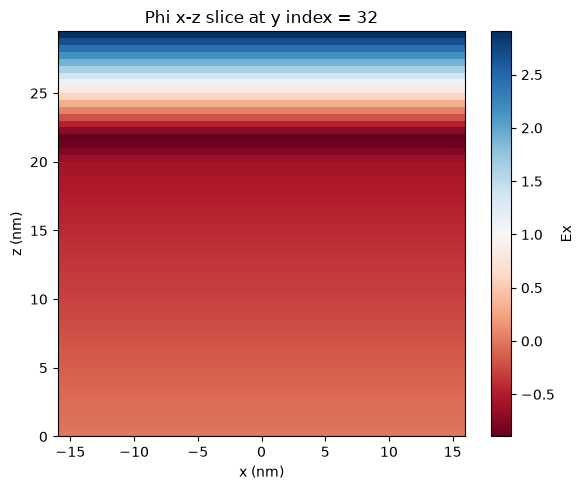

yt : [INFO     ] 2026-06-27 09:06:14,616 Parameters: current_time              = 4.903600000001137e-09


yt : [INFO     ] 2026-06-27 09:06:14,617 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:14,618 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:14,618 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


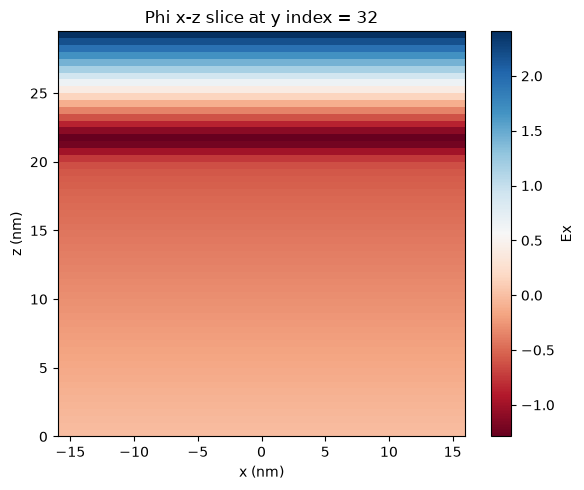

yt : [INFO     ] 2026-06-27 09:06:14,868 Parameters: current_time              = 4.91460000000114e-09


yt : [INFO     ] 2026-06-27 09:06:14,869 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:14,870 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:14,870 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


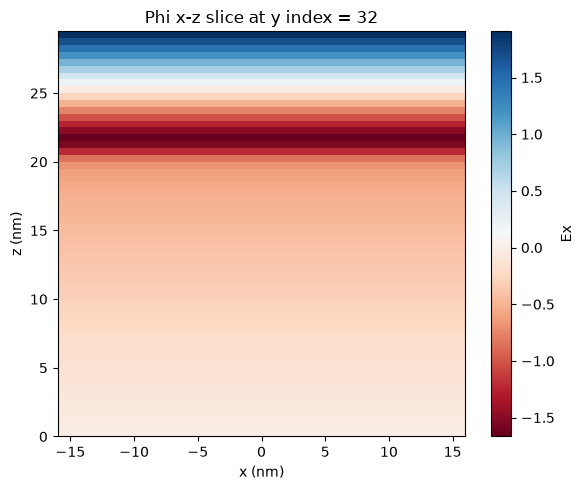

yt : [INFO     ] 2026-06-27 09:06:15,122 Parameters: current_time              = 4.924200000001143e-09


yt : [INFO     ] 2026-06-27 09:06:15,123 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:15,124 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:15,125 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


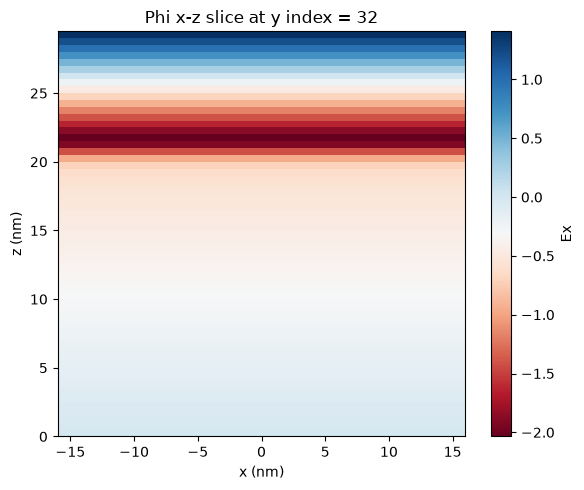

yt : [INFO     ] 2026-06-27 09:06:15,488 Parameters: current_time              = 4.9320000000011456e-09


yt : [INFO     ] 2026-06-27 09:06:15,489 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:15,490 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:15,491 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


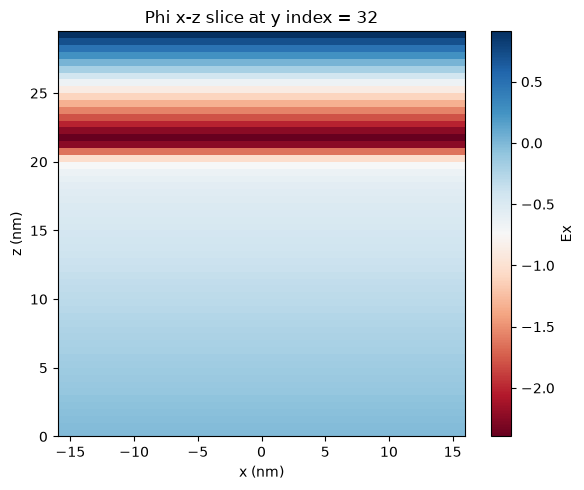

yt : [INFO     ] 2026-06-27 09:06:15,738 Parameters: current_time              = 4.939400000001148e-09


yt : [INFO     ] 2026-06-27 09:06:15,739 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:15,740 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:15,741 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


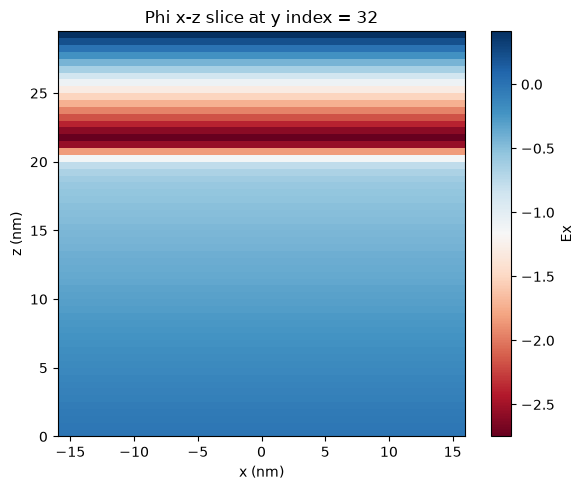

yt : [INFO     ] 2026-06-27 09:06:15,987 Parameters: current_time              = 4.94660000000115e-09


yt : [INFO     ] 2026-06-27 09:06:15,988 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:15,989 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:15,990 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


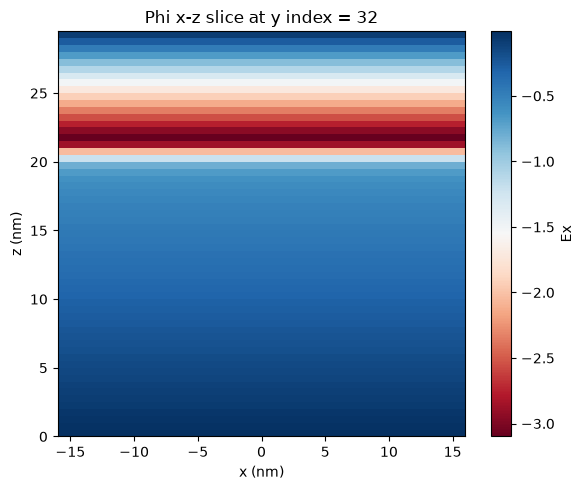

yt : [INFO     ] 2026-06-27 09:06:16,235 Parameters: current_time              = 4.953400000001152e-09


yt : [INFO     ] 2026-06-27 09:06:16,236 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:16,237 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:16,238 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


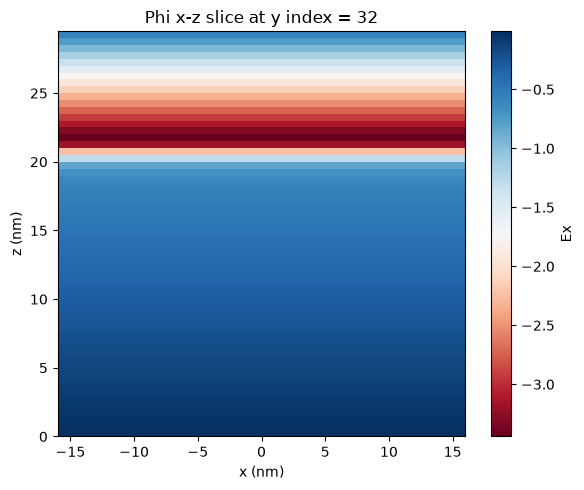

yt : [INFO     ] 2026-06-27 09:06:16,483 Parameters: current_time              = 4.959800000001154e-09


yt : [INFO     ] 2026-06-27 09:06:16,484 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:16,485 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:16,486 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


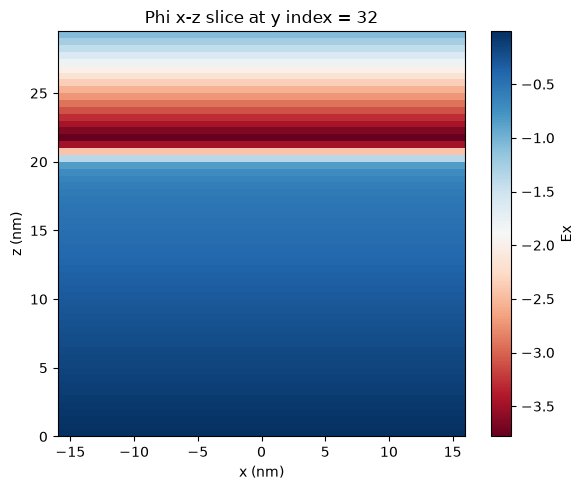

yt : [INFO     ] 2026-06-27 09:06:16,736 Parameters: current_time              = 4.966000000001156e-09


yt : [INFO     ] 2026-06-27 09:06:16,737 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:16,738 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:16,739 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


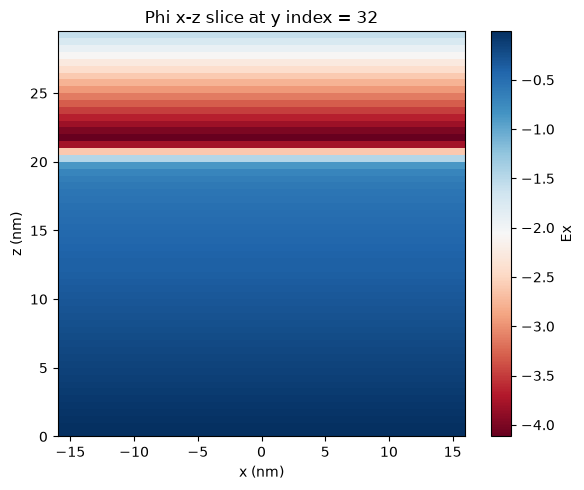

yt : [INFO     ] 2026-06-27 09:06:17,094 Parameters: current_time              = 4.971800000001158e-09


yt : [INFO     ] 2026-06-27 09:06:17,096 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:17,097 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:17,097 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


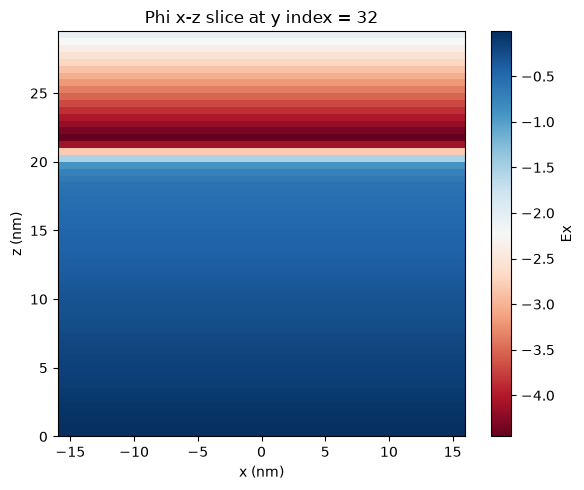

yt : [INFO     ] 2026-06-27 09:06:17,356 Parameters: current_time              = 4.9774000000011595e-09


yt : [INFO     ] 2026-06-27 09:06:17,357 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:17,358 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:17,360 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


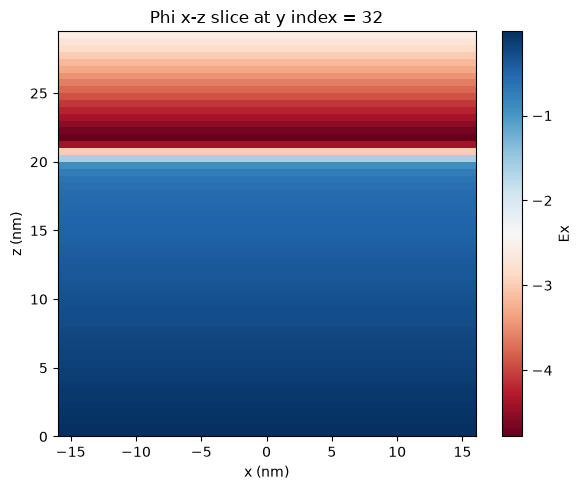

yt : [INFO     ] 2026-06-27 09:06:17,603 Parameters: current_time              = 4.982800000001161e-09


yt : [INFO     ] 2026-06-27 09:06:17,604 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:17,605 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:17,607 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


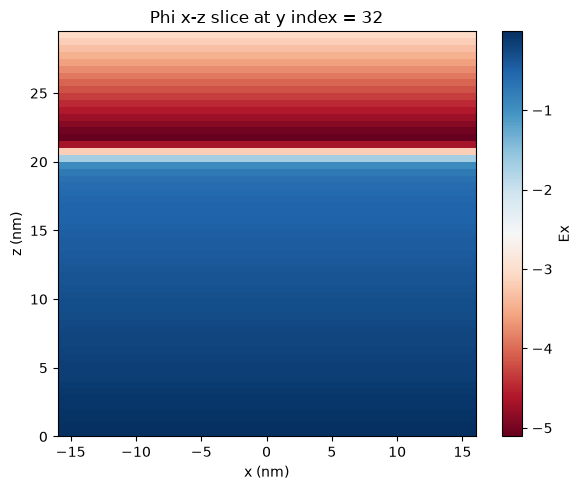

yt : [INFO     ] 2026-06-27 09:06:17,851 Parameters: current_time              = 4.988000000001163e-09


yt : [INFO     ] 2026-06-27 09:06:17,852 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:17,853 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:17,854 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


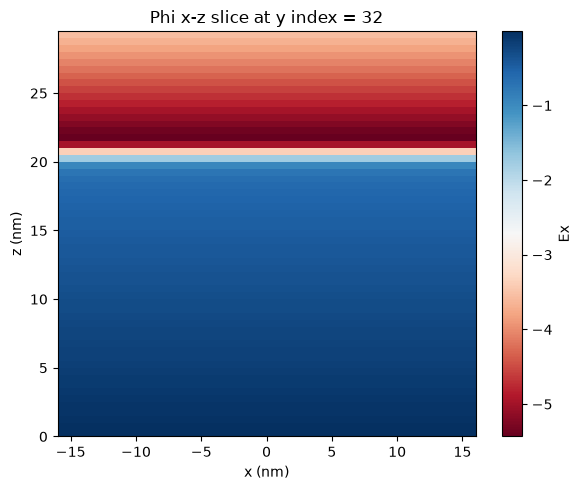

yt : [INFO     ] 2026-06-27 09:06:18,096 Parameters: current_time              = 4.993000000001164e-09


yt : [INFO     ] 2026-06-27 09:06:18,097 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:18,098 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:18,099 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


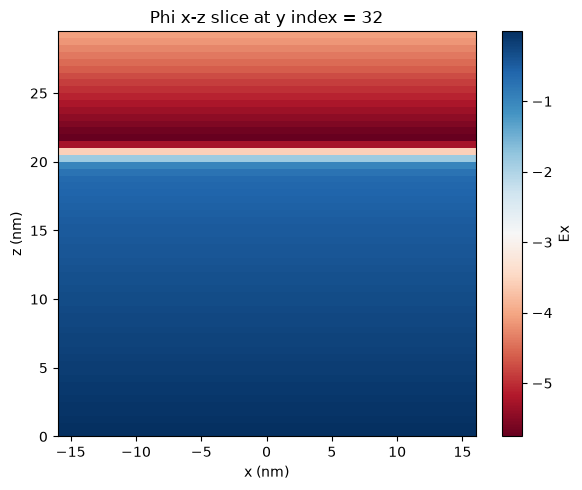

yt : [INFO     ] 2026-06-27 09:06:18,343 Parameters: current_time              = 4.997800000001166e-09


yt : [INFO     ] 2026-06-27 09:06:18,344 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:18,345 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:18,345 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


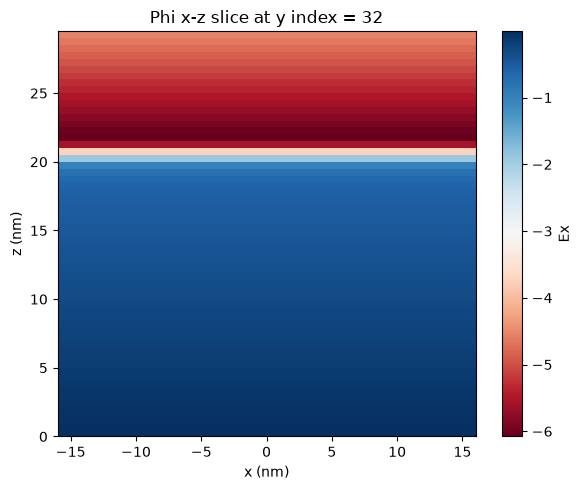

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-27 09:06:18,719 Parameters: current_time              = 1.1779999999999958e-10


yt : [INFO     ] 2026-06-27 09:06:18,720 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:18,721 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:18,723 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


E_array shape = (64, 64, 59)


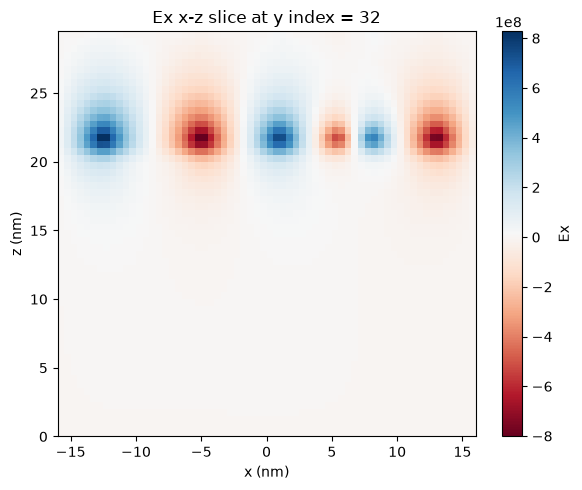

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

Plotfiles to draw:
  plt00023524
  plt00023549
  plt00023575
  plt00023602
  plt00023630
  plt00023659
  plt00023690
  plt00023722
  plt00023756
  plt00023791
  plt00023828
  plt00023867
  plt00023913
  plt00023966
  plt00024025
  plt00024090
  plt00024155
  plt00024214
  plt00024275
  plt00024335
  plt00024394
  plt00024458
  plt00024518
  plt00024573
  plt00024621
  plt00024660
  plt00024697
  plt00024733
  plt00024767
  plt00024799
  plt00024830
  plt00024859
  plt00024887
  plt00024914
  plt00024940
  plt00024965
  plt00024989
37 number of plotfiles will be drawn after filtering.


yt : [INFO     ] 2026-06-27 09:06:19,006 Parameters: current_time              = 4.704800000001076e-09


yt : [INFO     ] 2026-06-27 09:06:19,007 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:19,008 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:19,009 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


...

yt : [INFO     ] 2026-06-27 09:06:23,573 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:23,574 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:23,576 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Drawing 37 plots after filtering.


Saved figure: ./figs/Pz_FE_layer_stack.png


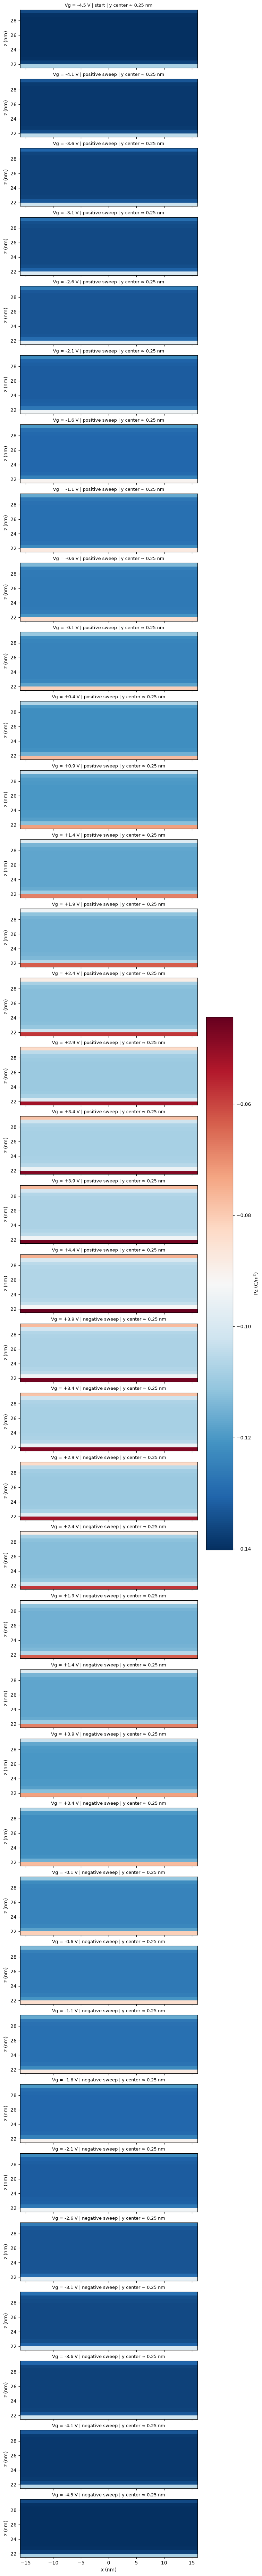

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [17]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [18]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-27 09:06:31,016 Parameters: current_time              = 4.704800000001076e-09


yt : [INFO     ] 2026-06-27 09:06:31,017 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:31,018 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:31,019 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


yt : [INFO     ] 2026-06-27 09:06:31,136 Parameters: current_time              = 4.709800000001077e-09


...

yt : [INFO     ] 2026-06-27 09:06:35,470 Parameters: current_time              = 4.997800000001166e-09


yt : [INFO     ] 2026-06-27 09:06:35,471 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-27 09:06:35,472 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-27 09:06:35,473 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Read Pz with shape (64, 64, 59) from plts/plt00024965
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00024965 | step=24965 | Vg=-4.0511 V | <Pz>_FE=+1.358878e-01
Read Pz with shape (64, 64, 59) from plts/plt00024989
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00024989 | step=24989 | Vg=-4.5464 V | <Pz>_FE=+1.375568e-01
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [19]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


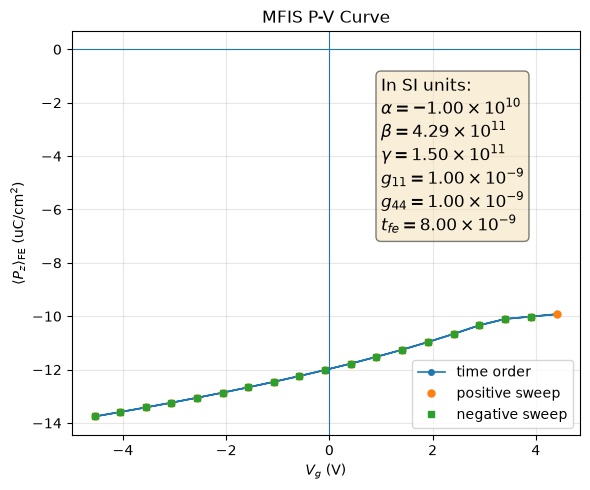

In [20]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()